**SETUP**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('pandas', pd.__version__)
print('numpy', np.__version__)
import sklearn; print('sklearn', sklearn.__version__)
from google.colab import files
uploaded=files.upload()

pandas 2.2.2
numpy 2.0.2
sklearn 1.6.1


Saving Housing.csv to Housing (1).csv


**PART 1: CLEANING THE DATA 🧹(ASSIGNMENT A)**

In [ ]:
#READING AND DISPLAYING
data=pd.read_csv('Housing.csv')
df=data.copy()
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
#INFORMATION
print(df.shape)
print(df.dtypes)
print(df.columns)


(545, 13)
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
#MISSING VALUES
df.isna().sum()


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.dropna()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
#DUPLICATES
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
#CONVERTING TO NUMERIC
df=pd.get_dummies(df,columns=['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True, dtype=int)
print(df)

        price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0    13300000  7420         4          2        3        2             1   
1    12250000  8960         4          4        4        3             1   
2    12250000  9960         3          2        2        2             1   
3    12215000  7500         4          2        2        3             1   
4    11410000  7420         4          1        2        2             1   
..        ...   ...       ...        ...      ...      ...           ...   
540   1820000  3000         2          1        1        2             1   
541   1767150  2400         3          1        1        0             0   
542   1750000  3620         2          1        1        0             1   
543   1750000  2910         3          1        1        0             0   
544   1750000  3850         3          1        2        0             1   

     guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0        

In [ ]:
#IQR-OUTLIERS
cols = ['price', 'area']

# 1. Calculate boundaries (axis=0 is default for columns)
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 2. Identify outliers using a boolean mask
mask = (df[cols] < lower) | (df[cols] > upper)

# 3. Report and Clip
print(f"Outliers found:\n{mask.sum()}")

# Clip handles both upper and lower bounds simultaneously
df[cols] = df[cols].clip(lower=lower, upper=upper, axis=1)




Outliers found:
price    15
area     12
dtype: int64


**PART 2: LINEAR REGRESSION MODEL😊 (ASSIGNMENT B)**

In [ ]:
#ASSIGNING
X=df[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','parking', 'prefarea', 'furnishingstatus']]
y=df[['price']]
X=pd.get_dummies(X,columns=['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True, dtype=int)
print(X.dtypes)
X = X.astype(float)
y = y.astype(float)
print(X.shape)
print(y.shape)

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                       int64
guestroom_yes                      int64
basement_yes                       int64
hotwaterheating_yes                int64
airconditioning_yes                int64
prefarea_yes                       int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object
(545, 13)
(545, 1)


In [ ]:
#SPLITIING
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for test
    random_state=42       # reproducibility — same split every run
)
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [ ]:
#TRAINING AND PREDICTION
model = LinearRegression()
model.fit(X_train, y_train)                           #  fit (= train)
y_pred = model.predict(X_test)                        # predict
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

#  Print with clear labels
print(f"MAE  (Mean Absolute Error):     {mae:.2f}")
print(f"MSE  (Mean Squared Error):      {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R2 Score:                       {r2:.4f}")


MAE  (Mean Absolute Error):     970043.40
MSE  (Mean Squared Error):      1754318687330.66
RMSE (Root Mean Squared Error): 1324506.96
R2 Score:                       0.6529


**R2 Score Analysis:**
The R2 Score (Coefficient of Determination) represents the proportion of variance in the Price that can be explained by the independent variables (like Area, Mainroad, and Furnishing Status) in the model.
R² (R-squared) = "how much of the wobble in y did our model explain?"  

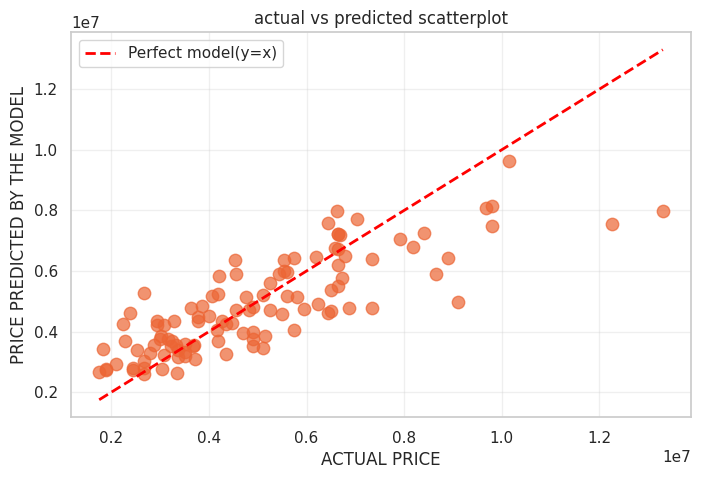

In [ ]:
#VISUALISATION-ACTUAL VS PREDICTED
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='#ec6534', s=80, alpha=0.7)
plt.xlabel('ACTUAL PRICE')
plt.ylabel('PRICE PREDICTED BY THE MODEL')
plt.title('actual vs predicted scatterplot')
plt.grid(True, alpha=0.3)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Perfect model(y=x)')
plt.legend()
plt.show()

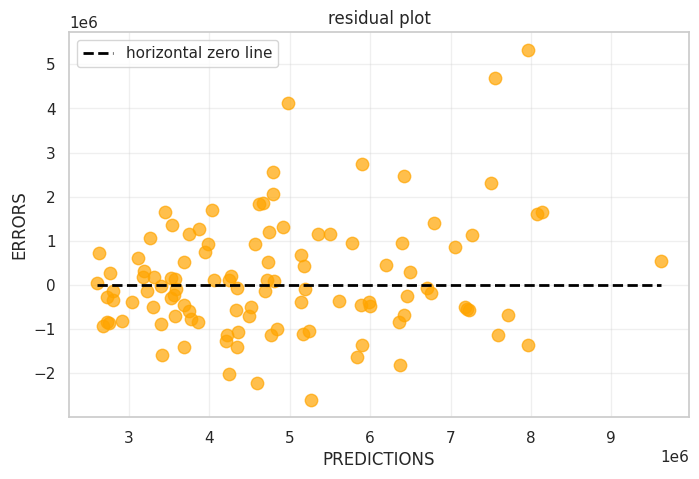

In [ ]:
#VISUALISATION-RESIDUALS
plt.figure(figsize=(8, 5))
residuals=y_test-y_pred
plt.scatter(y_pred, residuals, color='orange', s=80, alpha=0.7)
plt.xlabel('PREDICTIONS')
plt.ylabel('ERRORS')
plt.title('residual plot')
plt.grid(True, alpha=0.3)
line= [y_pred.min(), y_pred.max()]
plt.plot(line, [0,0], color='black', linestyle='--', lw=2, label='horizontal zero line')
plt.legend()
plt.show()

In [ ]:
#INSPECT THE COEFFICIENTS
coeffs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_.flatten()})

print(coeffs_df.to_string(index=False))


                        Feature   Coefficient
                           area  2.359688e+02
                       bedrooms  7.677870e+04
                      bathrooms  1.094445e+06
                        stories  4.074766e+05
                        parking  2.248419e+05
                   mainroad_yes  3.679199e+05
                  guestroom_yes  2.316100e+05
                   basement_yes  3.902512e+05
            hotwaterheating_yes  6.846499e+05
            airconditioning_yes  7.914267e+05
                   prefarea_yes  6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
   furnishingstatus_unfurnished -4.136451e+05


**Which feature
has the largest positive impact on price? Does that make real-world sense?**
The feature which has the largest positive impact on price is airconditioning_yes. This makes real-world sense because it serves as a 'luxury' indicator. While its importance varies between property types, the model shows that, on average, it provides the most significant price jump among all categorical features.

**ASSIGNMENT C-SELF STUDY: RANDOM FOREST🌳**( a .md is also created)

1.**What is an Ensemble Method? Why do we combine many models?**

*An ensemble method is a technique that combines multiple machine learning models to create a single, more powerful model. We combine them because "the group is smarter than the individual"; while a single model might make errors due to noise or bias, combining many models allows their individual errors to cancel out, leading to more stable and accurate predictions.*

**2. How does Bagging (Bootstrap Aggregating) work? What does it mean to “train
on a random sample”?**

*Bagging involves creating multiple different versions of the training set by picking rows at random with replacement (some rows appear twice, others not at all). "Training on a random sample" means each individual tree in the forest sees a slightly different "slice" of the data, which ensures that the trees don't all learn the exact same patterns and become redundant.*

**3. How is a Random Forest different from a single Decision Tree?**

*A single decision tree is often "high variance," meaning it is very sensitive to small changes in data and prone to overfitting. A Random Forest is a collection of many trees; by averaging their results, it smooths out the "quirks" of individual trees, making it much more robust and better at predicting prices for houses it hasn't seen before.*

**4. What is Feature Randomness — why does Random Forest randomly pick a
subset of features at each split?**

*Feature randomness forces each tree to choose its splitting point from a random group of columns (like area or bathrooms) rather than looking at all of them. This is done to prevent one very strong feature (like area) from dominating every single tree, which forces the forest to discover hidden patterns in other features like airconditioning or prefarea.*

**5. What does “majority voting” mean for classification? What about averaging for
regression?**

*In classification (predicting "Yes" or "No"), majority voting means the forest takes the answer chosen by the most trees. In regression (predicting a "Price"), the forest takes the numerical output from every tree and calculates the average; this average is the final predicted price, which helps reduce the impact of extreme or "wrong" guesses by individual trees.*

**6. What are the key hyperparameters: n estimators, max depth, max features?**

*  n_estimators: The number of trees you want to build (e.g., 100 or 500); more trees generally improve accuracy but take more time to train.
* max_depth: The maximum number of "levels" each tree can have; limiting this prevents trees from becoming too complex and memorizing the noise in the data.

*  max_features: The size of the random subset of features each tree looks at during a split, which controls how different the trees are from one another.





**7. What is Feature Importance in a Random Forest? How can it help explain which
inputs matter?**

*Feature importance is a score calculated by the forest that shows how much each feature helped reduce the error (uncertainty) across all trees. It helps explain the model by ranking features (like area vs. basement) based on their actual contribution to the final prediction, often providing a more reliable "ranking" than standard linear coefficients.*

**8. What are the strengths and weaknesses of Random Forest compared to a single Decision Tree?**

*The main strength of a Random Forest is its high accuracy and ability to handle complex, non-linear data without overfitting. Its primary weakness is that it is a "black box," meaning it is much harder for a human to visualize and explain exactly why the forest made a specific decision compared to the simple, clear logic of a single decision tree.*

**“Why does averaging many decision trees
reduce overfitting?”**

*Individual trees are very sensitive to "noise" (random quirks) in the training data. When you average many different trees, these random errors pull in opposite directions and cancel each other out, while the true underlying signal (the real relationship between features and price) remains consistent across the trees and is strengthened.*